# Brasileirão Série A 2026 — previsão de gols, resultados e análise de *green*

**Disciplina de Mineração de Dados — ADS, IFSP Câmpus Jacareí**

Notebook complementar ao `mineracao_bets.ipynb`. Enquanto aquele estuda a
eficiência do mercado nas ligas europeias, este responde a duas perguntas
diretas sobre o **Campeonato Brasileiro Série A de 2026**:

1. **O que deve acontecer nas partidas que ainda faltam?** Gols esperados de
   cada lado, placar mais provável, probabilidade de vitória, empate e derrota,
   mais de 2,5 gols, ambas as equipes marcarem — e como a tabela deve terminar.
2. **Qual a chance de voltar *green* em cada cotação?** Ou seja: apostando numa
   cotação qualquer, com que frequência a aposta ganha, e o que isso significa
   em dinheiro no longo prazo.

## Antes de tudo: o que esta base permite e o que não permite

A fonte (Football-Data.co.uk, arquivo do Brasil) traz, para cada partida,
**data, mandante, visitante, gols de cada lado, resultado e cotações**. É tudo.

**Não há finalizações, escanteios, cartões, posse de bola nem desarmes.** Então
"prever as estatísticas" aqui significa, honestamente, prever **tudo o que se
deriva de gols**:

| Dá para prever | Não dá com esta base |
|---|---|
| Gols esperados de cada time | Finalizações e chutes no alvo |
| Placar mais provável e probabilidade de cada placar | Escanteios |
| Vitória / empate / derrota | Cartões amarelos e vermelhos |
| Mais/menos de 2,5 gols | Posse de bola, passes, desarmes |
| Ambas as equipes marcam | Estatísticas individuais de jogadores |
| Classificação final simulada | |

Prever escanteios e cartões exigiria outra fonte de dados. Isso está registrado
em "Decisões e limitações", ao fim do notebook.

> **Nota.** Este é um trabalho de análise de dados sobre eficiência de mercado.
> A seção 6 mostra, com os números da própria base, que o retorno esperado é
> **negativo em todas as faixas de cotação** — inclusive quando se aposta
> apenas onde o modelo enxerga vantagem. Aposta é entretenimento com custo
> esperado, não fonte de renda.

In [1]:
# Ambiente. O módulo utils_brasileirao concentra coleta, modelo de gols e
# cálculo de green; utils traz as métricas genéricas (Wilson, RPS, log loss).
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd()
if not (RAIZ / "src").exists() and (RAIZ.parent / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import utils
import utils_brasileirao as ub

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
utils.estilo_padrao()

INICIO = time.time()
np.random.seed(ub.SEMENTE)

print("pandas :", pd.__version__)
print("semente:", ub.SEMENTE)
print("saídas :", ub.DIR_SAIDAS.relative_to(ub.RAIZ))

pandas : 2.2.3
semente: 42
saídas : outputs/brasileirao


---
## 1. Coleta

O Brasileirão fica num arquivo único que cobre todas as temporadas, em formato
diferente do das ligas europeias (que têm um CSV por temporada e divisão).

Como no outro notebook, a coleta tenta a **fonte oficial** e cai para um
**espelho público** quando o domínio está inacessível, gravando a origem em
disco para que o relatório nunca afirme "fonte oficial" sem ter falado com ela.

In [2]:
coleta = ub.baixar_base()
print("situação:", coleta["situacao"])
print("origem  :", coleta["origem"])
print("tamanho :", f"{coleta['bytes']/1024:.0f} KB")
if coleta["detalhe"]:
    print("detalhe :", coleta["detalhe"])

if coleta["origem"] == "espelho":
    print()
    print("=" * 78)
    print("AVISO: os dados vieram do ESPELHO PÚBLICO, não da fonte oficial.")
    print("O domínio football-data.co.uk está bloqueado neste ambiente.")
    print("Ver 'Decisões e limitações', ao fim do notebook.")
    print("=" * 78)

assert coleta["situacao"] != "falhou", coleta["detalhe"]

situação: cache
origem  : espelho
tamanho : 628 KB

AVISO: os dados vieram do ESPELHO PÚBLICO, não da fonte oficial.
O domínio football-data.co.uk está bloqueado neste ambiente.
Ver 'Decisões e limitações', ao fim do notebook.


In [3]:
base = ub.carregar_base()

print(f"Partidas na base : {len(base):,}".replace(",", "."))
print(f"Já disputadas    : {int(base['jogada'].sum()):,}".replace(",", "."))
print(f"Período          : {base['data'].min().date()} a {base['data'].max().date()}")
print(f"Temporadas       : {int(base['Season'].min())} a {int(base['Season'].max())}")
print()
print("Colunas disponíveis:")
print(" ", ", ".join(base.columns[:12]))
print(" ", ", ".join(base.columns[12:]))
print()
print("Partidas por temporada:")
print(base.groupby("Season").size().to_string())

Partidas na base : 5.597
Já disputadas    : 5.596
Período          : 2012-05-19 a 2026-09-20
Temporadas       : 2012 a 2026

Colunas disponíveis:
  Country, League, Season, Date, Time, Home, Away, HG, AG, Res, PSCH, PSCD
  PSCA, MaxCH, MaxCD, MaxCA, AvgCH, AvgCD, AvgCA, BFECH, BFECD, BFECA, B365CH, B365CD, B365CA, data, horario, partida_id, jogada

Partidas por temporada:
Season
2012    380
2013    380
2014    380
2015    380
2016    380
2017    380
2018    380
2019    380
2020    380
2021    380
2022    380
2023    380
2024    380
2025    380
2026    277


### 1.1 Cobertura das cotações

Duas particularidades importantes desta base, que mudam o que é possível fazer:

* **Só existem cotações de fechamento** (sufixo `C`) — a última cotação antes da
  bola rolar. Não há cotação de abertura nem de pré-jogo em outro momento.
* **Só existe o mercado 1X2** (mandante / empate / visitante). Não há cotações de
  mais/menos gols nem de ambas marcam, então a análise de *green* da seção 6 se
  restringe ao 1X2.

A escolha do operador de referência sai da tabela abaixo.

In [4]:
linhas = []
for temporada, grupo in base.groupby("Season"):
    linha = {"temporada": int(temporada), "n": len(grupo)}
    for nome, prefixo in ub.OPERADORES.items():
        colunas = ub.colunas_operador(prefixo)
        linha[nome] = (round(100 * grupo[colunas].notna().all(axis=1).mean(), 1)
                       if all(c in grupo.columns for c in colunas) else np.nan)
    linhas.append(linha)

cobertura = pd.DataFrame(linhas)
ub.salvar_tabela(cobertura, "cobertura_cotacoes")
print("Cobertura das cotações por temporada (% de partidas com o trio H/D/A):")
print(cobertura.to_string(index=False))
print()
print(f"Operador de referência escolhido: '{ub.OPERADOR_PADRAO}' "
      "(média de mercado, cotação de fechamento)")
print("Motivo: é o único com cobertura de 100% em todas as temporadas. A Bet365")
print("só aparece a partir de 2025 e a Pinnacle não cobre 2026.")

Cobertura das cotações por temporada (% de partidas com o trio H/D/A):
 temporada   n  Média de mercado  Máxima do mercado  Pinnacle  Betfair Exchange  Bet365
      2012 380             100.0              100.0     100.0               0.0     0.0
      2013 380             100.0              100.0     100.0               0.0     0.0
      2014 380             100.0              100.0     100.0               0.0     0.0
      2015 380             100.0              100.0     100.0               0.0     0.0
      2016 380             100.0              100.0      99.7               0.0     0.0
      2017 380             100.0              100.0     100.0               0.0     0.0
      2018 380             100.0              100.0     100.0               0.0     0.0
      2019 380             100.0              100.0     100.0               0.0     0.0
      2020 380             100.0              100.0     100.0               0.0     0.0
      2021 380             100.0              100

---
## 2. Panorama do Brasileirão

Antes de modelar, vale conhecer o campeonato. Esses números são a base de
comparação para tudo o que vem depois: se o modelo prevê 40% de empates, ele
está errado, porque o campeonato tem por volta de 27%.

In [5]:
historico = base[base["jogada"] & (base["Season"] < ub.TEMPORADA_ALVO)]
atual = base[base["jogada"] & (base["Season"] == ub.TEMPORADA_ALVO)]

def panorama(dados, rotulo):
    total_gols = dados["HG"] + dados["AG"]
    return {
        "recorte": rotulo, "partidas": len(dados),
        "gols_mandante": dados["HG"].mean(),
        "gols_visitante": dados["AG"].mean(),
        "gols_por_jogo": total_gols.mean(),
        "vitoria_mandante_pct": 100 * (dados["Res"] == "H").mean(),
        "empate_pct": 100 * (dados["Res"] == "D").mean(),
        "vitoria_visitante_pct": 100 * (dados["Res"] == "A").mean(),
        "over_25_pct": 100 * (total_gols > 2.5).mean(),
        "ambas_marcam_pct": 100 * ((dados["HG"] > 0) & (dados["AG"] > 0)).mean(),
    }

resumo = pd.DataFrame([panorama(historico, f"2012 a {ub.TEMPORADA_ALVO - 1}"),
                       panorama(atual, f"{ub.TEMPORADA_ALVO} (em andamento)")])
ub.salvar_tabela(resumo.round(4), "panorama")
print(resumo.round(2).to_string(index=False))
print()
print("Leitura: o mandante vence quase metade das partidas — a vantagem de jogar")
print("em casa é o efeito mais forte do campeonato. E 2026 está mais movimentado")
print("que a média histórica, o que o modelo precisa acompanhar.")

            recorte  partidas  gols_mandante  gols_visitante  gols_por_jogo  vitoria_mandante_pct  empate_pct  vitoria_visitante_pct  over_25_pct  ambas_marcam_pct
        2012 a 2025      5319           1.42            0.97           2.39                 48.52       26.85                  24.63        43.30             47.73
2026 (em andamento)       277           1.52            1.15           2.67                 46.93       27.80                  25.27        51.62             59.57

Leitura: o mandante vence quase metade das partidas — a vantagem de jogar
em casa é o efeito mais forte do campeonato. E 2026 está mais movimentado
que a média histórica, o que o modelo precisa acompanhar.


---
## 3. As partidas que ainda faltam

O Brasileirão é disputado em **pontos corridos, turno e returno**: cada time
enfrenta todos os outros duas vezes, uma em casa e uma fora. Com 20 clubes, o
calendário tem exatamente **20 × 19 = 380 confrontos**, um para cada par
ordenado (mandante, visitante).

Isso tem uma consequência prática muito útil: **não é preciso baixar tabela de
jogos nenhuma**. O que falta é simplesmente o conjunto de pares ordenados que
ainda não apareceram na base. A conta fecha sozinha e o notebook confere isso
com um `assert`.

In [6]:
restantes, times_2026, n_disputadas = ub.partidas_restantes(base, ub.TEMPORADA_ALVO)

print(f"Times em {ub.TEMPORADA_ALVO}: {len(times_2026)}")
print(" ", ", ".join(times_2026))
print()
print(f"Partidas já disputadas : {n_disputadas}")
print(f"Partidas restantes     : {len(restantes)}")
print(f"Total do calendário    : {n_disputadas + len(restantes)}")
print(f"Esperado (20 x 19)     : {ub.PARTIDAS_POR_TEMPORADA}")

assert len(times_2026) == ub.TIMES_POR_TEMPORADA, "número de times diferente de 20"
assert n_disputadas + len(restantes) == ub.PARTIDAS_POR_TEMPORADA, "calendário não fecha"
print()
print("Conferido: o calendário fecha exatamente.")
print(f"Última partida disputada: {atual['data'].max().date()}")
print()
print("Primeiras partidas restantes:")
print(restantes.head(8).to_string(index=False))

Times em 2026: 20
  Athletico-PR, Atletico-MG, Bahia, Botafogo RJ, Bragantino, Chapecoense-SC, Corinthians, Coritiba, Cruzeiro, Flamengo RJ, Fluminense, Gremio, Internacional, Mirassol, Palmeiras, Remo, Santos, Sao Paulo, Vasco, Vitoria

Partidas já disputadas : 277
Partidas restantes     : 103
Total do calendário    : 380
Esperado (20 x 19)     : 380

Conferido: o calendário fecha exatamente.
Última partida disputada: 2026-09-20

Primeiras partidas restantes:
 Season         Home        Away
   2026 Athletico-PR Atletico-MG
   2026 Athletico-PR   Palmeiras
   2026 Athletico-PR        Remo
   2026 Athletico-PR   Sao Paulo
   2026 Athletico-PR       Vasco
   2026  Atletico-MG  Bragantino
   2026  Atletico-MG Corinthians
   2026  Atletico-MG    Coritiba


In [7]:
# Classificação no momento do corte.
tabela = ub.classificacao(base, ub.TEMPORADA_ALVO)
ub.salvar_tabela(tabela, "classificacao_atual")
print(f"CLASSIFICAÇÃO APÓS {n_disputadas} PARTIDAS "
      f"(até {atual['data'].max().date()})")
print(tabela.to_string(index=False))

CLASSIFICAÇÃO APÓS 277 PARTIDAS (até 2026-09-20)
 posicao           time  jogos  pontos  vitorias  gols_pro  gols_contra  saldo
       1    Flamengo RJ     28      60        18      55.0         23.0   32.0
       2      Palmeiras     28      57        16      47.0         21.0   26.0
       3   Athletico-PR     28      49        14      43.0         32.0   11.0
       4     Fluminense     28      48        13      44.0         36.0    8.0
       5          Bahia     28      46        12      43.0         35.0    8.0
       6       Cruzeiro     28      45        13      42.0         40.0    2.0
       7    Atletico-MG     27      40        11      36.0         32.0    4.0
       8         Santos     27      38        10      41.0         40.0    1.0
       9       Coritiba     28      38        10      37.0         43.0   -6.0
      10     Bragantino     27      36        10      33.0         31.0    2.0
      11      Sao Paulo     27      36        10      32.0         30.0    2.0
   

---
## 4. O modelo de gols

### 4.1 A ideia

Em vez de prever o resultado diretamente, o modelo prevê **quantos gols cada
time deve marcar**. Resultado, total de gols e "ambas marcam" saem todos daí.
É a abordagem clássica para futebol, porque gol é evento raro e contável — o
tipo de coisa que a **distribuição de Poisson** descreve bem.

Cada time entra com dois números:

* **ataque** — o quanto marca, comparado à média da liga;
* **defesa** — o quanto sofre, comparado à média da liga.

O número esperado de gols de um confronto combina os dois lados, mais a
vantagem de jogar em casa:

$$\log(\lambda) = \text{intercepto} + \text{ataque}_{\text{time}} + \text{defesa}_{\text{adversário}} + \text{mando}$$

Cada partida vira **duas observações** (uma por time), e os coeficientes saem de
uma regressão de Poisson.

### 4.2 Dois ajustes que importam

**Peso temporal.** Um jogo de 2013 não diz quase nada sobre o elenco de 2026.
Cada partida é ponderada por um decaimento exponencial: uma partida de uma
**meia-vida** atrás pesa metade de uma partida de hoje. A meia-vida é escolhida
por validação, nunca no olho.

**Correção de Dixon-Coles.** O Poisson simples trata os gols dos dois times como
independentes e, com isso, **subestima 0-0 e 1-1** — justamente os placares de
jogo travado. A correção ajusta essas quatro células de placar baixo; o tamanho
do ajuste (`rho`) é estimado **nos dados de treino**.

In [8]:
# Escolha da meia-vida por validação temporal: treina até a temporada anterior
# e mede o log loss na temporada seguinte, para várias temporadas.
TEMPORADAS_VALIDACAO = [2022, 2023, 2024, 2025]
MEIAS_VIDAS = [120, 180, 365, 730, 1460]

linhas = []
for meia_vida in MEIAS_VIDAS:
    perdas = []
    for temporada in TEMPORADAS_VALIDACAO:
        treino = base[(base["Season"] < temporada) & base["jogada"]]
        alvo = base[(base["Season"] == temporada) & base["jogada"]]
        modelo = ub.ajustar_modelo_gols(treino, treino["data"].max(), meia_vida)
        previsto = modelo.prever(alvo[["Home", "Away"]])
        perdas.append(utils.log_loss_ordenado(
            alvo["Res"].to_numpy(),
            previsto[["prob_H", "prob_D", "prob_A"]].to_numpy()))
    linhas.append({"meia_vida_dias": meia_vida, "log_loss_medio": float(np.mean(perdas)),
                   **{f"log_loss_{t}": p for t, p in zip(TEMPORADAS_VALIDACAO, perdas)}})

validacao = pd.DataFrame(linhas).sort_values("log_loss_medio")
ub.salvar_tabela(validacao.round(6), "validacao_meia_vida")
MEIA_VIDA = int(validacao.iloc[0]["meia_vida_dias"])

print("Escolha da meia-vida (menor log loss é melhor):")
print(validacao.round(5).to_string(index=False))
print()
print(f"Meia-vida escolhida: {MEIA_VIDA} dias "
      f"(uma partida de {MEIA_VIDA} dias atrás pesa metade de uma de hoje)")

Escolha da meia-vida (menor log loss é melhor):
 meia_vida_dias  log_loss_medio  log_loss_2022  log_loss_2023  log_loss_2024  log_loss_2025
            730         1.03115        1.04748        1.02953        1.03903        1.00858
           1460         1.03121        1.04436        1.02871        1.04001        1.01174
            365         1.03456        1.05712        1.03260        1.03922        1.00930
            180         1.04504        1.07274        1.04008        1.04749        1.01985
            120         1.05487        1.08261        1.04870        1.05873        1.02945

Meia-vida escolhida: 730 dias (uma partida de 730 dias atrás pesa metade de uma de hoje)


### 4.3 Times sem histórico

Um detalhe que quebra modelos ingênuos: **times recém-promovidos não têm
histórico na Série A**. Em 2026 é o caso do **Remo**, que não aparece na base
entre 2012 e 2025.

A solução aqui é explícita: um time sem histórico recebe o **perfil médio dos
promovidos** da janela de treino — a informação honesta disponível sobre quem
acabou de subir. Quando o modelo final é ajustado (já incluindo as partidas de
2026), o Remo passa a ter coeficientes próprios e o recurso deixa de ser
necessário.

In [9]:
# Modelo final: ajustado com TODAS as partidas já disputadas, inclusive 2026.
# Para prever o futuro, usar o passado inteiro não é vazamento — é o correto.
disputadas = base[base["jogada"]]
modelo = ub.ajustar_modelo_gols(disputadas, disputadas["data"].max(), MEIA_VIDA)

print(f"Partidas no ajuste      : {modelo.n_partidas:,}".replace(",", "."))
print(f"Meia-vida               : {modelo.meia_vida_dias} dias")
print(f"Correção Dixon-Coles rho: {modelo.rho:+.4f}")
print(f"Vantagem de mando       : {modelo.mando:+.4f} "
      f"(o mandante marca {100*(np.exp(modelo.mando)-1):.1f}% a mais)")
print()
sem_historico = modelo.sem_historico(times_2026)
print("Times de 2026 sem histórico no modelo final:",
      sem_historico if sem_historico else "nenhum")

Partidas no ajuste      : 5.596
Meia-vida               : 730 dias
Correção Dixon-Coles rho: +0.0117
Vantagem de mando       : +0.3381 (o mandante marca 40.2% a mais)

Times de 2026 sem histórico no modelo final: nenhum


In [10]:
forcas = modelo.forca_dos_times()
forcas_2026 = forcas[forcas["time"].isin(times_2026)].reset_index(drop=True)
ub.salvar_tabela(forcas_2026, "forca_dos_times")

print("FORÇA DE ATAQUE E DEFESA (1,00 = média da liga)")
print("ataque acima de 1 -> marca mais que a média")
print("defesa abaixo de 1 -> sofre menos que a média")
print()
print(forcas_2026.round(3).to_string(index=False))

FORÇA DE ATAQUE E DEFESA (1,00 = média da liga)
ataque acima de 1 -> marca mais que a média
defesa abaixo de 1 -> sofre menos que a média

          time  ataque  defesa  saldo
     Palmeiras   1.540   0.575  2.680
   Flamengo RJ   1.675   0.633  2.648
      Cruzeiro   1.199   0.695  1.726
   Botafogo RJ   1.317   0.764  1.724
    Fluminense   1.223   0.743  1.646
      Mirassol   1.333   0.818  1.629
   Atletico-MG   1.233   0.760  1.622
  Athletico-PR   1.205   0.760  1.585
     Sao Paulo   1.132   0.734  1.542
 Internacional   1.171   0.780  1.501
         Bahia   1.256   0.851  1.475
   Corinthians   1.101   0.752  1.464
    Bragantino   1.169   0.834  1.402
        Gremio   1.193   0.855  1.395
        Santos   1.187   0.877  1.355
         Vasco   1.174   0.963  1.219
       Vitoria   0.984   0.913  1.079
      Coritiba   1.092   1.058  1.032
          Remo   1.083   1.066  1.016
Chapecoense-SC   0.939   1.155  0.813


Figura: outputs/brasileirao/figuras/forca_dos_times.png


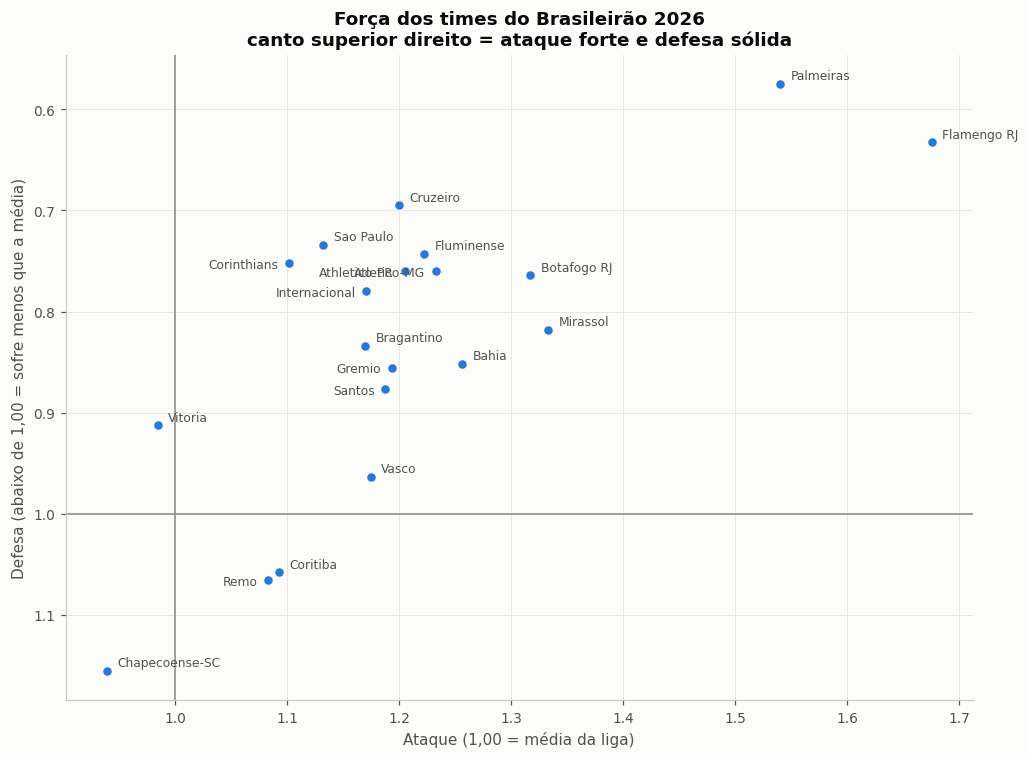

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 7))

x = forcas_2026["ataque"].to_numpy()
y = forcas_2026["defesa"].to_numpy()

# Uma série só -> uma cor. As linhas de referência marcam a média da liga.
ax.axvline(1.0, color=utils.TINTA_SUAVE, linewidth=1.0, zorder=1)
ax.axhline(1.0, color=utils.TINTA_SUAVE, linewidth=1.0, zorder=1)
ax.scatter(x, y, s=46, color=utils.CORES_SERIES[0], zorder=3,
           edgecolor=utils.SUPERFICIE, linewidth=1.2)

# Desvio simples de colisão: quando dois times caem quase no mesmo ponto
# (Athletico-PR e Atletico-MG, por exemplo), o segundo rótulo vai para baixo.
colocados = []
escala_x = (x.max() - x.min()) or 1.0
escala_y = (y.max() - y.min()) or 1.0
for nome, xi, yi in zip(forcas_2026["time"], x, y):
    perto = any(abs(xi - px) / escala_x < 0.09 and abs(yi - py) / escala_y < 0.06
                for px, py in colocados)
    # Descer o rótulo não basta quando os dois começam no mesmo x: o vizinho vai
    # para o lado oposto do ponto.
    deslocamento, alinhamento = ((-7, -3), "right") if perto else ((7, 3), "left")
    ax.annotate(nome, (xi, yi), textcoords="offset points", xytext=deslocamento,
                ha=alinhamento, fontsize=8, color=utils.TINTA_SECUNDARIA)
    colocados.append((xi, yi))

# O eixo y é invertido (defesa melhor para cima), então o canto forte é o
# SUPERIOR direito: muito ataque e pouco gol sofrido.
ax.set_title("Força dos times do Brasileirão 2026\n"
             "canto superior direito = ataque forte e defesa sólida")
ax.set_xlabel("Ataque (1,00 = média da liga)")
ax.set_ylabel("Defesa (abaixo de 1,00 = sofre menos que a média)")
ax.invert_yaxis()          # defesa melhor para cima
fig.tight_layout()
print("Figura:", ub.salvar_figura(fig, "forca_dos_times").relative_to(ub.RAIZ))
plt.show()

---
## 5. O modelo funciona? Validação *walk-forward*

Um modelo só vale pelo que acerta em jogos que **não viu**. O teste aqui é
*walk-forward*: para cada temporada de 2016 a 2026, o modelo é treinado apenas
com o que veio **antes** dela e prevê a temporada inteira. Nenhuma previsão usa
informação do próprio ano.

A referência é o **mercado** — as cotações de fechamento, que embutem tudo o que
as casas sabiam minutos antes da bola rolar.

In [12]:
inicio_wf = time.time()
partes = []
for temporada in range(2016, ub.TEMPORADA_ALVO + 1):
    treino = base[(base["Season"] < temporada) & base["jogada"]]
    alvo = base[(base["Season"] == temporada) & base["jogada"]]
    if alvo.empty:
        continue
    modelo_wf = ub.ajustar_modelo_gols(treino, treino["data"].max(), MEIA_VIDA)
    previsto = modelo_wf.prever(alvo[["Home", "Away"]])
    mercado_wf, _ = ub.probabilidades_mercado(alvo)
    previsto["Season"] = temporada
    previsto["Res"] = alvo["Res"].to_numpy()
    previsto["HG"] = alvo["HG"].to_numpy()
    previsto["AG"] = alvo["AG"].to_numpy()
    previsto[["mkt_H", "mkt_D", "mkt_A"]] = mercado_wf.to_numpy()
    previsto[["cot_H", "cot_D", "cot_A"]] = alvo[ub.colunas_operador(
        ub.OPERADOR_PADRAO)].to_numpy()
    partes.append(previsto)

walk = pd.concat(partes, ignore_index=True)
print(f"Previsões fora da amostra: {len(walk):,} partidas, "
      f"{walk['Season'].nunique()} temporadas "
      f"({time.time()-inicio_wf:.1f}s)".replace(",", "."))

y_walk = walk["Res"].to_numpy()
P_modelo = walk[["prob_H", "prob_D", "prob_A"]].to_numpy()
P_mercado = walk[["mkt_H", "mkt_D", "mkt_A"]].to_numpy()

def avaliar(nome, probabilidades, tem_probabilidade=True):
    predicao = np.array(utils.CLASSES)[probabilidades.argmax(axis=1)]
    return {"previsor": nome,
            "acuracia": float((predicao == y_walk).mean()),
            # "Sempre mandante" é uma regra sem probabilidade própria: aplicar
            # log loss a uma previsão 1/0/0 mede o valor de corte do cálculo,
            # não a qualidade do previsor. O RPS, esse sim, é bem definido.
            "log_loss": (utils.log_loss_ordenado(y_walk, probabilidades)
                         if tem_probabilidade else np.nan),
            "rps": utils.rps(y_walk, probabilidades)}

comparacao = pd.DataFrame([
    avaliar("Modelo de gols (Poisson/Dixon-Coles)", P_modelo),
    avaliar("Mercado (cotação de fechamento)", P_mercado),
    avaliar("Sempre mandante", np.tile([1.0, 0.0, 0.0], (len(walk), 1)),
            tem_probabilidade=False),
])
ub.salvar_tabela(comparacao.round(6), "comparacao_modelo_mercado")
print()
print(comparacao.round(4).to_string(index=False))
print("(log loss não se aplica a 'sempre mandante', que não emite probabilidade)")

diferenca, inferior, superior = utils.bootstrap_pareado_acuracia(
    (np.array(utils.CLASSES)[P_modelo.argmax(1)] == y_walk).astype(int),
    (np.array(utils.CLASSES)[P_mercado.argmax(1)] == y_walk).astype(int))
print()
print(f"Diferença de acurácia (modelo - mercado): {100*diferenca:+.2f} p.p. "
      f"IC 95% [{100*inferior:+.2f}; {100*superior:+.2f}]")
print("O mercado continua à frente, como nas ligas europeias.")

Previsões fora da amostra: 4.076 partidas. 11 temporadas (4.8s)

                            previsor  acuracia  log_loss    rps
Modelo de gols (Poisson/Dixon-Coles)    0.4885    1.0310 0.2108
     Mercado (cotação de fechamento)    0.5125    0.9983 0.2005
                     Sempre mandante    0.4777       NaN 0.3863
(log loss não se aplica a 'sempre mandante', que não emite probabilidade)



Diferença de acurácia (modelo - mercado): -2.40 p.p. IC 95% [-3.46; -1.40]
O mercado continua à frente, como nas ligas europeias.


### 5.1 Calibração dos mercados de gols

Acertar o vencedor é só parte do trabalho. Para quem olha mercados de gols, o
que importa é se a **probabilidade** está certa: quando o modelo diz 45% de mais
de 2,5 gols, isso acontece em 45% das vezes?

A tabela abaixo compara o previsto com o observado nas 4 mil partidas fora da
amostra. **Esse é o número mais importante desta seção** — e ele revela um viés
que precisa ser declarado.

In [13]:
walk["over_25_real"] = ((walk["HG"] + walk["AG"]) > 2.5).astype(int)
walk["ambas_marcam_real"] = ((walk["HG"] > 0) & (walk["AG"] > 0)).astype(int)
walk["empate_real"] = (walk["Res"] == "D").astype(int)

linhas = []
for rotulo, coluna_prevista, coluna_real in [
        ("Vitória do mandante", "prob_H", None),
        ("Empate", "prob_D", "empate_real"),
        ("Mais de 2,5 gols", "prob_over_25", "over_25_real"),
        ("Ambas as equipes marcam", "prob_ambas_marcam", "ambas_marcam_real")]:
    real = (walk["Res"] == "H").astype(int) if coluna_real is None else walk[coluna_real]
    previsto_medio = walk[coluna_prevista].mean()
    observado = real.mean()
    inferior, superior = utils.ic_wilson(np.array([real.sum()]), np.array([len(real)]))
    linhas.append({"mercado": rotulo,
                   "previsto_medio": previsto_medio, "observado": observado,
                   "obs_ic95_inferior": float(inferior[0]),
                   "obs_ic95_superior": float(superior[0]),
                   "vies_pp": 100 * (previsto_medio - observado),
                   "calibrado": bool(inferior[0] <= previsto_medio <= superior[0])})

calibracao_gols = pd.DataFrame(linhas)
ub.salvar_tabela(calibracao_gols.round(6), "calibracao_mercados_gols")

print("CALIBRAÇÃO FORA DA AMOSTRA (2016 a 2026, "
      f"{len(walk):,} partidas)".replace(",", "."))
print()
for _, linha in calibracao_gols.iterrows():
    marca = "OK" if linha["calibrado"] else "VIESADO"
    print(f"   {linha['mercado']:26s} previsto {100*linha['previsto_medio']:5.2f}% | "
          f"observado {100*linha['observado']:5.2f}% "
          f"[{100*linha['obs_ic95_inferior']:5.2f}; {100*linha['obs_ic95_superior']:5.2f}] | "
          f"viés {linha['vies_pp']:+5.2f} p.p. -> {marca}")

print()
print("ATENÇÃO — o viés de 'ambas as equipes marcam' é o maior e é sistemático.")
print("A causa é conhecida: o modelo supõe que os gols dos dois times são")
print("independentes, e na prática eles são positivamente correlacionados (jogo")
print("aberto costuma ter gol dos dois lados). Por isso o modelo SUBESTIMA esse")
print("mercado. É a previsão menos confiável do notebook, e quem for usá-la deve")
print("somar o viés medido acima.")

CALIBRAÇÃO FORA DA AMOSTRA (2016 a 2026. 4.076 partidas)

   Vitória do mandante        previsto 47.69% | observado 47.77% [46.24; 49.30] | viés -0.08 p.p. -> OK
   Empate                     previsto 25.98% | observado 27.21% [25.86; 28.60] | viés -1.22 p.p. -> OK
   Mais de 2,5 gols           previsto 41.97% | observado 43.57% [42.06; 45.10] | viés -1.61 p.p. -> VIESADO
   Ambas as equipes marcam    previsto 44.58% | observado 48.75% [47.22; 50.28] | viés -4.17 p.p. -> VIESADO

ATENÇÃO — o viés de 'ambas as equipes marcam' é o maior e é sistemático.
A causa é conhecida: o modelo supõe que os gols dos dois times são
independentes, e na prática eles são positivamente correlacionados (jogo
aberto costuma ter gol dos dois lados). Por isso o modelo SUBESTIMA esse
mercado. É a previsão menos confiável do notebook, e quem for usá-la deve
somar o viés medido acima.


---
## 6. A chance de voltar *green* em cada cotação

Esta é a pergunta central do notebook, e ela esconde **duas perguntas
diferentes**. Separar as duas é o que evita a confusão mais comum de quem
aposta.

> **Pergunta 1 (olhando para trás).** Entre todas as apostas historicamente
> oferecidas a uma cotação de, digamos, 2,00 — quantas voltaram green?
>
> **Pergunta 2 (olhando para frente).** Dada a probabilidade que o modelo
> atribui a um desfecho, qual a chance de green e quanto vale a pena pagar
> por ela?

A seção 6.1 responde a primeira com os dados; a 6.2 responde a segunda com
aritmética; a 6.3 testa se dá para ganhar dinheiro juntando as duas.

**Vocabulário.** Apostando 1 unidade numa cotação `c`: o *green* devolve `c − 1`
de lucro, o *red* perde a unidade.

### 6.1 Quanto volta green, historicamente, em cada faixa

Cada partida gera **três apostas** — uma em cada desfecho — com a cotação de
fechamento da média de mercado. A comparação que interessa não é a taxa de green
sozinha, e sim a taxa de green **contra a probabilidade implícita na cotação**
(`1 / cotação`).

Se a cotação fosse um preço justo, as duas seriam iguais. A diferença entre elas
é o que a casa cobra.

In [14]:
apostas = ub.empilhar_desfechos(base, ub.OPERADOR_PADRAO)
green = ub.green_por_faixa(apostas)
ub.salvar_tabela(green.round(6), "green_por_faixa_cotacao")

print(f"Apostas simuladas: {len(apostas):,} "
      f"({len(apostas)//3:,} partidas x 3 desfechos)".replace(",", "."))
print()
print("TAXA DE GREEN POR FAIXA DE COTAÇÃO (média de mercado, fechamento)")
print()
cabecalho = (f"{'faixa':>12} {'n':>6} {'green':>8} {'IC 95%':>16} "
             f"{'implícita':>10} {'diferença':>10} {'retorno':>9}")
print(cabecalho)
print("-" * len(cabecalho))
for _, linha in green.iterrows():
    print(f"{str(linha['faixa_cotacao']):>12} {int(linha['n_apostas']):>6} "
          f"{100*linha['taxa_green']:>7.2f}% "
          f"[{100*linha['green_ic95_inferior']:>5.2f};{100*linha['green_ic95_superior']:>6.2f}] "
          f"{100*linha['prob_implicita_media']:>9.2f}% "
          f"{100*(linha['taxa_green']-linha['prob_implicita_media']):>+9.2f} "
          f"{100*linha['retorno_medio']:>+8.2f}%")

print()
print("Leitura: em TODAS as faixas a taxa de green fica abaixo da probabilidade")
print("implícita, e o retorno médio é negativo. A diferença cresce nas cotações")
print("altas — é o viés favorito-azarão, o mesmo das ligas europeias.")

Apostas simuladas: 16.788 (5.596 partidas x 3 desfechos)

TAXA DE GREEN POR FAIXA DE COTAÇÃO (média de mercado, fechamento)

       faixa      n    green           IC 95%  implícita  diferença   retorno
-----------------------------------------------------------------------------
     até 1,5    692   70.66% [67.17; 73.94]     72.96%     -2.29    -3.30%
     1,5 a 2   2249   56.74% [54.68; 58.77]     57.70%     -0.97    -1.65%
       2 a 3   4013   39.42% [37.92; 40.94]     40.45%     -1.03    -2.61%
       3 a 5   8009   24.95% [24.01; 25.91]     28.32%     -3.37   -12.46%
      5 a 10   1703   14.33% [12.74; 16.07]     15.98%     -1.65   -10.90%
 acima de 10    122    5.74% [ 2.81; 11.37]      8.32%     -2.58   -31.83%

Leitura: em TODAS as faixas a taxa de green fica abaixo da probabilidade
implícita, e o retorno médio é negativo. A diferença cresce nas cotações
altas — é o viés favorito-azarão, o mesmo das ligas europeias.


Figura: outputs/brasileirao/figuras/green_por_faixa.png


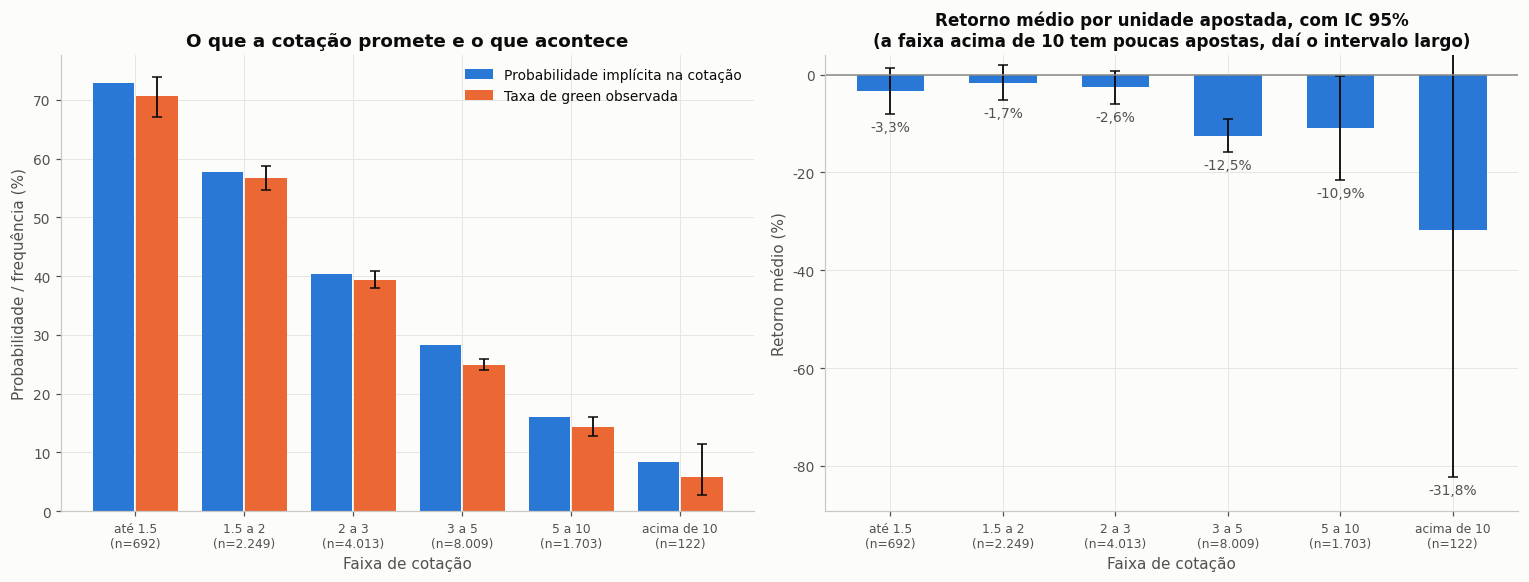

In [15]:
fig, (esq, dir) = plt.subplots(1, 2, figsize=(14, 5.4))

posicao = np.arange(len(green))
largura = 0.38
# Duas séries -> dois primeiros slots da paleta.
esq.bar(posicao - largura/2 - 0.01, 100*green["prob_implicita_media"], largura,
        label="Probabilidade implícita na cotação", color=utils.CORES_SERIES[0])
esq.bar(posicao + largura/2 + 0.01, 100*green["taxa_green"], largura,
        label="Taxa de green observada", color=utils.CORES_SERIES[1])
erro = np.vstack([100*(green["taxa_green"] - green["green_ic95_inferior"]),
                  100*(green["green_ic95_superior"] - green["taxa_green"])])
esq.errorbar(posicao + largura/2 + 0.01, 100*green["taxa_green"], yerr=erro,
             fmt="none", ecolor=utils.TINTA_PRIMARIA, elinewidth=1.2, capsize=3)
esq.set_title("O que a cotação promete e o que acontece")
esq.set_xlabel("Faixa de cotação")
esq.set_ylabel("Probabilidade / frequência (%)")
esq.set_xticks(posicao)
# O n entra no rótulo: é ele que explica por que a última faixa tem intervalo
# tão largo (poucas apostas acima de 10).
rotulos_faixa = [f"{faixa}\n(n={int(n):,})".replace(",", ".")
                 for faixa, n in zip(green["faixa_cotacao"].astype(str),
                                     green["n_apostas"])]
esq.set_xticklabels(rotulos_faixa, rotation=0, fontsize=8)
esq.legend()

retorno = 100*green["retorno_medio"].to_numpy()
inferiores = 100*green["retorno_ic95_inferior"].to_numpy()
erro_ret = np.vstack([retorno - inferiores,
                      100*green["retorno_ic95_superior"].to_numpy() - retorno])
dir.bar(posicao, retorno, 0.6, color=utils.CORES_SERIES[0])
dir.errorbar(posicao, retorno, yerr=erro_ret, fmt="none",
             ecolor=utils.TINTA_PRIMARIA, elinewidth=1.2, capsize=3)
dir.axhline(0, color=utils.TINTA_SUAVE, linewidth=1.0)
for p, valor, inferior in zip(posicao, retorno, inferiores):
    dir.text(p, inferior - 1.2, utils.formatar_br(valor, 1) + "%", ha="center",
             va="top", fontsize=9, color=utils.TINTA_SECUNDARIA)
dir.set_ylim(inferiores.min() - 7, 4)
dir.set_title("Retorno médio por unidade apostada, com IC 95%\n"
              "(a faixa acima de 10 tem poucas apostas, daí o intervalo largo)",
              fontsize=11)
dir.set_xlabel("Faixa de cotação")
dir.set_ylabel("Retorno médio (%)")
dir.set_xticks(posicao)
dir.set_xticklabels(rotulos_faixa, rotation=0, fontsize=8)

fig.tight_layout()
print("Figura:", ub.salvar_figura(fig, "green_por_faixa").relative_to(ub.RAIZ))
plt.show()

### 6.2 A aritmética: a cotação não muda a chance de green

Aqui está o ponto que mais confunde. Considere um desfecho com probabilidade
real de 40%:

* a **chance de green é 40%**, seja a cotação 1,50 ou 5,00. A cotação é o preço,
  não o risco;
* o que muda com a cotação é **quanto se recebe por acertar**, e portanto o
  **valor esperado**: `VE = p × cotação − 1`;
* existe uma **cotação de equilíbrio**, `1 / p`. Abaixo dela a aposta perde
  dinheiro no longo prazo por construção, mesmo acertando 40% das vezes.

A tabela abaixo deixa isso explícito: a coluna "chance de green" não muda.

In [16]:
EXEMPLO_P = 0.40
demonstracao = ub.tabela_green_por_cotacao(EXEMPLO_P)
ub.salvar_tabela(demonstracao.round(6), "exemplo_green_por_cotacao")

print(f"Desfecho com probabilidade real de {100*EXEMPLO_P:.0f}% "
      f"(cotação de equilíbrio: {1/EXEMPLO_P:.2f})")
print()
print(f"{'cotação':>8} {'chance green':>13} {'implícita':>10} "
      f"{'lucro se green':>15} {'valor esperado':>15} {'vale a pena?':>13}")
print("-" * 80)
for _, linha in demonstracao.iterrows():
    print(f"{linha['cotacao_oferecida']:>8.2f} "
          f"{100*linha['chance_green']:>12.1f}% "
          f"{100*linha['prob_implicita']:>9.1f}% "
          f"{linha['retorno_se_green']:>+15.2f} "
          f"{100*linha['valor_esperado']:>+14.1f}% "
          f"{('SIM' if linha['vale_a_pena'] else 'não'):>13}")
print()
print("A chance de green é a mesma em todas as linhas. O que muda é o preço.")
print("Conclusão prática: não existe 'cotação com mais chance de green' —")
print("existe cotação cara e cotação barata para um mesmo risco.")

Desfecho com probabilidade real de 40% (cotação de equilíbrio: 2.50)

 cotação  chance green  implícita  lucro se green  valor esperado  vale a pena?
--------------------------------------------------------------------------------
    1.20         40.0%      83.3%           +0.20          -52.0%           não
    1.50         40.0%      66.7%           +0.50          -40.0%           não
    1.80         40.0%      55.6%           +0.80          -28.0%           não
    2.00         40.0%      50.0%           +1.00          -20.0%           não
    2.50         40.0%      40.0%           +1.50           +0.0%           não
    3.00         40.0%      33.3%           +2.00          +20.0%           SIM
    4.00         40.0%      25.0%           +3.00          +60.0%           SIM
    5.00         40.0%      20.0%           +4.00         +100.0%           SIM
    7.00         40.0%      14.3%           +6.00         +180.0%           SIM
   10.00         40.0%      10.0%           +9.00

### 6.3 E se apostar só onde o modelo vê vantagem?

Essa é a ideia natural: usar o modelo para achar as apostas em que a
probabilidade estimada é **maior** que a implícita na cotação — as chamadas
apostas de valor — e apostar só nelas.

O teste abaixo faz exatamente isso, usando **apenas as previsões fora da
amostra** da seção 5 (nenhuma delas viu o próprio resultado). Para cada nível de
exigência de valor esperado, mede-se o retorno realmente obtido.

É o teste mais duro do notebook, e o resultado é inequívoco.

In [17]:
linhas = []
for classe, coluna_prob, coluna_cot in [("H", "prob_H", "cot_H"),
                                        ("D", "prob_D", "cot_D"),
                                        ("A", "prob_A", "cot_A")]:
    linhas.append(pd.DataFrame({
        "Season": walk["Season"], "desfecho": classe,
        "p_modelo": walk[coluna_prob], "cotacao": walk[coluna_cot],
        "green": (walk["Res"] == classe).astype(int)}))

teste_valor = pd.concat(linhas, ignore_index=True).dropna(subset=["cotacao"])
teste_valor["valor_esperado"] = teste_valor["p_modelo"] * teste_valor["cotacao"] - 1
teste_valor["retorno"] = np.where(teste_valor["green"] == 1,
                                  teste_valor["cotacao"] - 1.0, -1.0)

def resumir(selecao, rotulo):
    if len(selecao) < 30:
        return None
    media = selecao["retorno"].mean()
    erro = selecao["retorno"].std(ddof=1) / np.sqrt(len(selecao))
    return {"estrategia": rotulo, "n_apostas": len(selecao),
            "taxa_green": selecao["green"].mean(),
            "cotacao_media": selecao["cotacao"].mean(),
            "retorno_medio": media,
            "ic95_inferior": media - 1.96*erro, "ic95_superior": media + 1.96*erro,
            "lucro_total": selecao["retorno"].sum()}

resultados = [resumir(teste_valor, "Apostar em tudo")]
for limite in (0.0, 0.05, 0.10, 0.20):
    resultados.append(resumir(teste_valor[teste_valor["valor_esperado"] > limite],
                              f"Só com VE > {utils.formatar_br(100*limite, 0)}%"))
backtest = pd.DataFrame([r for r in resultados if r])
ub.salvar_tabela(backtest.round(6), "backtest_apostas_de_valor")

print("BACKTEST — apostas de 1 unidade, previsões fora da amostra "
      f"({walk['Season'].min()} a {walk['Season'].max()})")
print()
print(f"{'estratégia':>22} {'n':>6} {'green':>8} {'cot.méd':>8} "
      f"{'retorno':>9} {'IC 95%':>20} {'lucro':>10}")
print("-" * 90)
for _, linha in backtest.iterrows():
    print(f"{linha['estrategia']:>22} {int(linha['n_apostas']):>6} "
          f"{100*linha['taxa_green']:>7.1f}% {linha['cotacao_media']:>8.2f} "
          f"{100*linha['retorno_medio']:>+8.2f}% "
          f"[{100*linha['ic95_inferior']:>+7.2f};{100*linha['ic95_superior']:>+7.2f}] "
          f"{linha['lucro_total']:>+10.1f}")

melhor = backtest.loc[backtest["retorno_medio"].idxmax()]
print()
print(f"Melhor estratégia testada: {melhor['estrategia']} "
      f"({100*melhor['retorno_medio']:+.2f}% por unidade)")
FILTRO_PIORA = bool(backtest.iloc[1:]["retorno_medio"].max()
                    < backtest.iloc[0]["retorno_medio"])
print(f"Filtrar por valor esperado MELHORA o retorno? "
      f"{'não' if FILTRO_PIORA else 'sim'}")

BACKTEST — apostas de 1 unidade, previsões fora da amostra (2016 a 2026)

            estratégia      n    green  cot.méd   retorno               IC 95%      lucro
------------------------------------------------------------------------------------------
       Apostar em tudo  12228    33.3%     3.38    -7.88% [ -10.50;  -5.26]     -963.8
        Só com VE > 0%   4217    27.0%     4.16   -12.33% [ -17.30;  -7.36]     -519.8
        Só com VE > 5%   3374    25.6%     4.38   -13.64% [ -19.32;  -7.96]     -460.3
       Só com VE > 10%   2724    24.1%     4.61   -14.50% [ -20.99;  -8.00]     -394.9
       Só com VE > 20%   1824    20.9%     5.08   -17.54% [ -25.84;  -9.23]     -319.8

Melhor estratégia testada: Apostar em tudo (-7.88% por unidade)
Filtrar por valor esperado MELHORA o retorno? não


Figura: outputs/brasileirao/figuras/backtest_apostas_de_valor.png


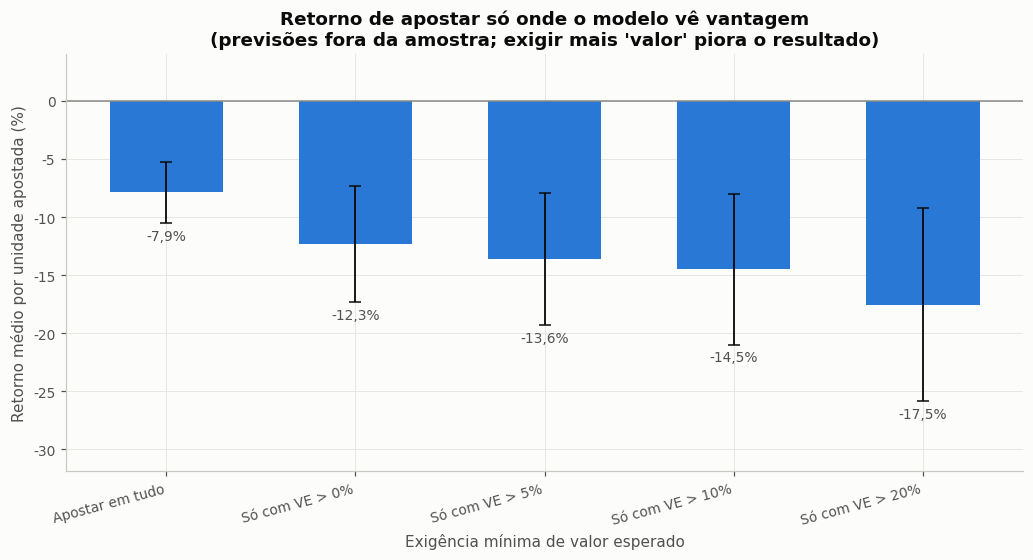

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))

posicao = np.arange(len(backtest))
retorno = 100*backtest["retorno_medio"].to_numpy()
inferiores = 100*backtest["ic95_inferior"].to_numpy()
erro = np.vstack([retorno - inferiores,
                  100*backtest["ic95_superior"].to_numpy() - retorno])

ax.bar(posicao, retorno, 0.6, color=utils.CORES_SERIES[0])
ax.errorbar(posicao, retorno, yerr=erro, fmt="none", ecolor=utils.TINTA_PRIMARIA,
            elinewidth=1.2, capsize=4)
ax.axhline(0, color=utils.TINTA_SUAVE, linewidth=1.0)
for p, valor, inferior in zip(posicao, retorno, inferiores):
    ax.text(p, inferior - 0.5, utils.formatar_br(valor, 1) + "%", ha="center",
            va="top", fontsize=9, color=utils.TINTA_SECUNDARIA)

ax.set_title("Retorno de apostar só onde o modelo vê vantagem\n"
             "(previsões fora da amostra; exigir mais 'valor' piora o resultado)")
ax.set_xlabel("Exigência mínima de valor esperado")
ax.set_ylabel("Retorno médio por unidade apostada (%)")
ax.set_xticks(posicao)
ax.set_xticklabels(backtest["estrategia"], rotation=15, ha="right")
ax.set_ylim(inferiores.min() - 6, 4)
fig.tight_layout()
print("Figura:", ub.salvar_figura(fig, "backtest_apostas_de_valor").relative_to(ub.RAIZ))
plt.show()

**O que esse resultado significa.** Apertar o filtro de valor **piora** o
retorno em vez de melhorar. A explicação é direta: quando o modelo discorda
muito do mercado, na esmagadora maioria das vezes **quem está errado é o
modelo**, não o mercado. O filtro acaba selecionando justamente os azarões em
que o modelo está mais otimista — e são esses os que menos voltam green.

É a mesma conclusão do notebook das ligas europeias, agora com dados brasileiros
e por um caminho independente.

---
## 7. Previsão das partidas que faltam

Agora o modelo final é aplicado às partidas restantes. Para cada uma, a matriz
de placares gera tudo de uma vez: gols esperados, placar mais provável,
probabilidade de cada desfecho, mais de 2,5 gols e ambas marcarem.

A coluna **`cotacao_minima_*`** é a mais útil para quem vai comparar com uma casa
de apostas: é a cotação abaixo da qual aquela aposta tem valor esperado negativo
segundo o modelo.

In [19]:
previsoes = modelo.prever(restantes)

for classe in utils.CLASSES:
    previsoes[f"cotacao_minima_{classe}"] = 1.0 / previsoes[f"prob_{classe}"]
previsoes["cotacao_minima_over_25"] = 1.0 / previsoes["prob_over_25"]
previsoes["cotacao_minima_ambas_marcam"] = 1.0 / previsoes["prob_ambas_marcam"]
previsoes["favorito"] = np.where(
    previsoes["prob_H"] >= previsoes[["prob_D", "prob_A"]].max(axis=1),
    previsoes["Home"],
    np.where(previsoes["prob_A"] >= previsoes["prob_D"], previsoes["Away"], "Empate"))

previsoes = previsoes.sort_values(["Home", "Away"]).reset_index(drop=True)
caminho = ub.salvar_tabela(previsoes.round(5), "previsoes_partidas_restantes")

print(f"{len(previsoes)} partidas previstas -> {caminho.relative_to(ub.RAIZ)}")
print()
print("Médias das partidas restantes:")
print(f"   gols esperados por jogo : {previsoes['gols_esperados_total'].mean():.2f}")
print(f"   vitória do mandante     : {100*previsoes['prob_H'].mean():.1f}%")
print(f"   empate                  : {100*previsoes['prob_D'].mean():.1f}%")
print(f"   vitória do visitante    : {100*previsoes['prob_A'].mean():.1f}%")
print(f"   mais de 2,5 gols        : {100*previsoes['prob_over_25'].mean():.1f}%")
print(f"   ambas as equipes marcam : {100*previsoes['prob_ambas_marcam'].mean():.1f}% "
      "(lembrar do viés medido na seção 5.1)")

103 partidas previstas -> outputs/brasileirao/tabelas/previsoes_partidas_restantes.csv

Médias das partidas restantes:
   gols esperados por jogo : 2.60
   vitória do mandante     : 47.5%
   empate                  : 24.6%
   vitória do visitante    : 27.9%
   mais de 2,5 gols        : 47.9%
   ambas as equipes marcam : 49.4% (lembrar do viés medido na seção 5.1)


In [20]:
colunas_mostrar = ["Home", "Away", "lambda_mandante", "lambda_visitante",
                   "placar_mais_provavel", "prob_H", "prob_D", "prob_A",
                   "prob_over_25", "prob_ambas_marcam",
                   "cotacao_minima_H", "cotacao_minima_D", "cotacao_minima_A"]

print("AS 15 PARTIDAS RESTANTES COM FAVORITO MAIS CLARO")
print("(gols esperados, placar mais provável e cotação mínima de cada desfecho)")
print()
mais_definidas = previsoes.assign(
    confianca=previsoes[["prob_H", "prob_D", "prob_A"]].max(axis=1)
).nlargest(15, "confianca")
print(mais_definidas[colunas_mostrar].round(3).to_string(index=False))

print()
print("AS 10 PARTIDAS MAIS EQUILIBRADAS")
print()
mais_equilibradas = previsoes.assign(
    confianca=previsoes[["prob_H", "prob_D", "prob_A"]].max(axis=1)
).nsmallest(10, "confianca")
print(mais_equilibradas[colunas_mostrar].round(3).to_string(index=False))

AS 15 PARTIDAS RESTANTES COM FAVORITO MAIS CLARO
(gols esperados, placar mais provável e cotação mínima de cada desfecho)

          Home           Away  lambda_mandante  lambda_visitante placar_mais_provavel  prob_H  prob_D  prob_A  prob_over_25  prob_ambas_marcam  cotacao_minima_H  cotacao_minima_D  cotacao_minima_A
   Flamengo RJ Chapecoense-SC            2.916             0.638                  2-0   0.834   0.111   0.055         0.689              0.446             1.199             8.998            18.279
     Palmeiras           Remo            2.474             0.669                  2-0   0.770   0.149   0.081         0.608              0.446             1.298             6.733            12.317
     Palmeiras       Coritiba            2.456             0.675                  2-0   0.766   0.151   0.083         0.605              0.448             1.305             6.643            12.023
   Botafogo RJ Chapecoense-SC            2.293             0.771                  2-0   0

---
## 8. Como deve terminar o campeonato

As previsões partida a partida viram uma previsão de temporada por **simulação
de Monte Carlo**: as partidas restantes são jogadas 10 mil vezes, sorteando o
placar da matriz de probabilidades de cada jogo — e não fixando o resultado mais
provável. É isso que preserva a incerteza: um jogo de 55% para o mandante termina
em vitória dele em 55% das simulações, não em todas.

Desempate aplicado: pontos, vitórias, saldo de gols e gols pró.

In [21]:
inicio_sim = time.time()
N_SIMULACOES = 10_000
simulacao = ub.simular_temporada(modelo, restantes, tabela,
                                 n_simulacoes=N_SIMULACOES, semente=ub.SEMENTE)
ub.salvar_tabela(simulacao.round(6), "simulacao_final_temporada")

print(f"{N_SIMULACOES:,} simulações em {time.time()-inicio_sim:.1f}s"
      .replace(",", "."))
print()
print(f"{'time':>16} {'pts hoje':>9} {'pts final':>10} {'pos.méd':>8} "
      f"{'título':>8} {'G4':>7} {'G6':>7} {'Z4':>7}")
print("-" * 80)
for _, linha in simulacao.iterrows():
    print(f"{linha['time']:>16} {int(linha['pontos_atuais']):>9} "
          f"{linha['pontos_esperados']:>10.1f} {linha['posicao_media']:>8.1f} "
          f"{100*linha['prob_titulo']:>7.1f}% {100*linha['prob_g4']:>6.1f}% "
          f"{100*linha['prob_g6']:>6.1f}% {100*linha['prob_z4']:>6.1f}%")

assert abs(simulacao["prob_titulo"].sum() - 1.0) < 1e-6
assert abs(simulacao["prob_z4"].sum() - 4.0) < 1e-6
print()
print("Conferido: as probabilidades de título somam 1 e as de Z4 somam 4.")

10.000 simulações em 0.2s

            time  pts hoje  pts final  pos.méd   título      G4      G6      Z4
--------------------------------------------------------------------------------
     Flamengo RJ        60       79.3      1.3    68.8%  100.0%  100.0%    0.0%
       Palmeiras        57       76.8      1.7    31.1%  100.0%  100.0%    0.0%
    Athletico-PR        49       63.5      4.1     0.1%   69.6%   94.3%    0.0%
      Fluminense        48       63.1      4.4     0.0%   62.0%   92.0%    0.0%
        Cruzeiro        45       60.1      5.4     0.0%   34.4%   76.9%    0.0%
           Bahia        46       58.7      6.2     0.0%   19.6%   60.9%    0.0%
     Atletico-MG        40       56.1      7.3     0.0%    9.7%   38.0%    0.0%
       Sao Paulo        36       52.1      9.5     0.0%    1.8%   12.5%    0.8%
      Bragantino        36       51.4      9.9     0.0%    1.2%    8.5%    1.0%
     Botafogo RJ        35       51.3     10.1     0.0%    0.6%    7.1%    1.4%
          Sa

Figura: outputs/brasileirao/figuras/simulacao_temporada.png


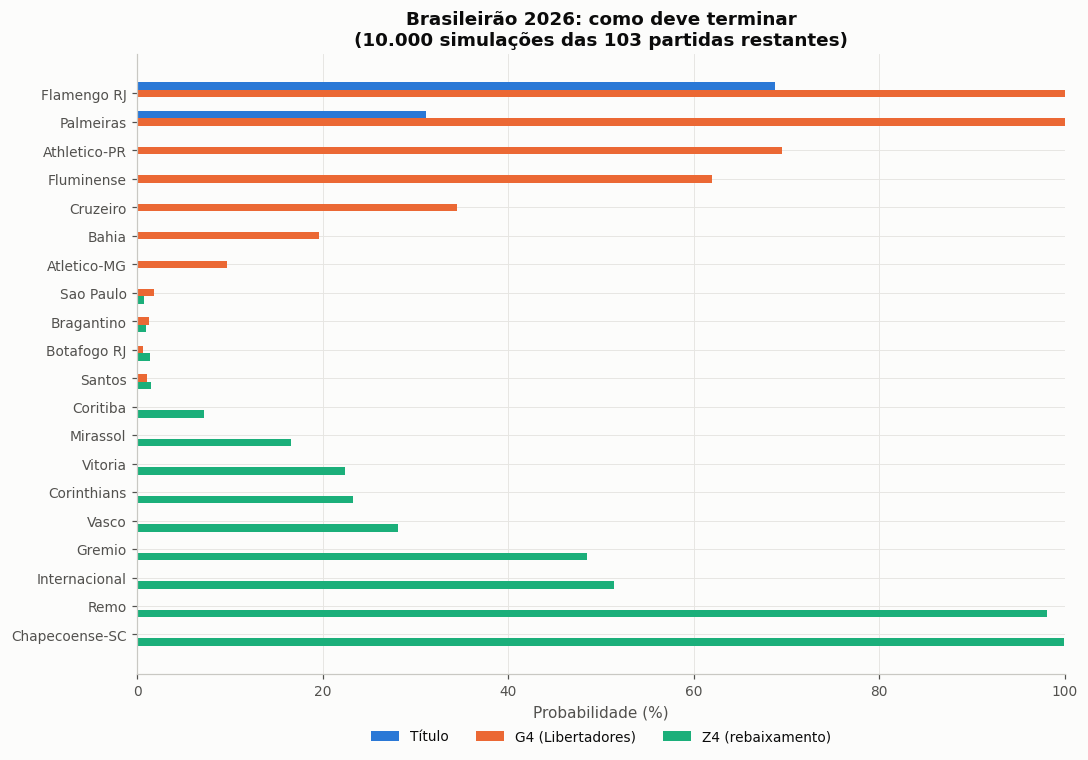

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

ordenado = simulacao.sort_values("posicao_media", ascending=False)
posicao = np.arange(len(ordenado))
altura = 0.26

# Três desfechos de temporada -> três primeiros slots, sempre na mesma ordem.
for deslocamento, coluna, rotulo, cor in (
        (+altura, "prob_titulo", "Título", utils.CORES_SERIES[0]),
        (0.0, "prob_g4", "G4 (Libertadores)", utils.CORES_SERIES[1]),
        (-altura, "prob_z4", "Z4 (rebaixamento)", utils.CORES_SERIES[2])):
    ax.barh(posicao + deslocamento, 100*ordenado[coluna], altura,
            label=rotulo, color=cor)

ax.set_title(f"Brasileirão {ub.TEMPORADA_ALVO}: como deve terminar\n"
             f"({N_SIMULACOES:,} simulações das {len(restantes)} partidas restantes)"
             .replace(",", "."))
ax.set_xlabel("Probabilidade (%)")
ax.set_yticks(posicao)
ax.set_yticklabels(ordenado["time"], fontsize=9)
# Legenda fora da área de plotagem: no canto inferior direito ela cobriria as
# barras de rebaixamento de Remo e Chapecoense, que chegam a 100%.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=3)
ax.set_xlim(0, 100)
fig.tight_layout()
print("Figura:", ub.salvar_figura(fig, "simulacao_temporada").relative_to(ub.RAIZ))
plt.show()

---
## 9. Resumo dos resultados

Esta seção grava `outputs/brasileirao/resumo_brasileirao_2026.txt` com as
respostas diretas às duas perguntas do notebook. Nenhum número é digitado à mão.

In [23]:
linhas = []
adicionar = linhas.append

adicionar("=" * 78)
adicionar(f"BRASILEIRÃO SÉRIE A {ub.TEMPORADA_ALVO} — PREVISÕES E ANÁLISE DE GREEN")
adicionar("Mineração de Dados — ADS, IFSP Câmpus Jacareí")
adicionar("=" * 78)
adicionar(f"Gerado em {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}")
adicionar(f"Dados até {atual['data'].max().date()} | origem: {coleta['origem']}")
adicionar("")

adicionar("-" * 78)
adicionar("1. SITUAÇÃO DO CAMPEONATO")
adicionar("-" * 78)
adicionar(f"Partidas disputadas : {n_disputadas} de {ub.PARTIDAS_POR_TEMPORADA}")
adicionar(f"Partidas restantes  : {len(restantes)}")
adicionar(f"Líder               : {tabela.iloc[0]['time']} "
          f"({int(tabela.iloc[0]['pontos'])} pontos)")
adicionar("")

adicionar("-" * 78)
adicionar("2. O MODELO")
adicionar("-" * 78)
adicionar("Poisson com correção de Dixon-Coles, ponderado no tempo.")
adicionar(f"   meia-vida escolhida por validação : {MEIA_VIDA} dias")
adicionar(f"   correção de placar baixo (rho)    : {utils.formatar_br(modelo.rho, 4)}")
adicionar(f"   vantagem de mando                 : o mandante marca "
          f"{utils.formatar_br(100*(np.exp(modelo.mando)-1), 1)}% a mais")
adicionar(f"   partidas usadas no ajuste         : {modelo.n_partidas}")
adicionar("")
adicionar(f"Desempenho fora da amostra ({len(walk)} partidas, "
          f"{walk['Season'].min()}-{walk['Season'].max()}):")
for _, linha in comparacao.iterrows():
    perda = ("não se aplica" if pd.isna(linha["log_loss"])
             else utils.formatar_br(linha["log_loss"], 5))
    adicionar(f"   {linha['previsor']:38s} acurácia "
              f"{utils.formatar_br(100*linha['acuracia'], 2)}% | "
              f"log loss {perda} | "
              f"RPS {utils.formatar_br(linha['rps'], 5)}")
adicionar("")
adicionar("Calibração dos mercados de gols (previsto x observado):")
for _, linha in calibracao_gols.iterrows():
    adicionar(f"   {linha['mercado']:26s} previsto "
              f"{utils.formatar_br(100*linha['previsto_medio'], 2)}% | observado "
              f"{utils.formatar_br(100*linha['observado'], 2)}% | viés "
              f"{utils.formatar_br(linha['vies_pp'], 2)} p.p. "
              f"{'(calibrado)' if linha['calibrado'] else '(VIESADO)'}")
adicionar("")

adicionar("-" * 78)
adicionar("3. CHANCE DE GREEN POR FAIXA DE COTAÇÃO")
adicionar("-" * 78)
adicionar("Média de mercado, cotação de fechamento, 2012 a 2026.")
adicionar("")
adicionar(f"   {'faixa':>12} {'apostas':>8} {'green':>8} {'implícita':>10} "
          f"{'retorno':>9}")
for _, linha in green.iterrows():
    adicionar(f"   {str(linha['faixa_cotacao']):>12} {int(linha['n_apostas']):>8} "
              f"{utils.formatar_br(100*linha['taxa_green'], 2):>7}% "
              f"{utils.formatar_br(100*linha['prob_implicita_media'], 2):>9}% "
              f"{utils.formatar_br(100*linha['retorno_medio'], 2):>8}%")
adicionar("")
adicionar("   Em todas as faixas a taxa de green fica ABAIXO da probabilidade")
adicionar("   implícita, e o retorno médio é NEGATIVO. A diferença cresce nas")
adicionar("   cotações altas (viés favorito-azarão).")
adicionar("")
adicionar("   A chance de green de um desfecho é a probabilidade dele acontecer —")
adicionar("   a cotação não altera essa chance, altera o preço pago por ela.")
adicionar("   Cotação de equilíbrio = 1 / probabilidade.")
adicionar("")

adicionar("-" * 78)
adicionar("4. DÁ PARA GANHAR APOSTANDO ONDE O MODELO VÊ VANTAGEM?")
adicionar("-" * 78)
for _, linha in backtest.iterrows():
    adicionar(f"   {linha['estrategia']:>22} | n = {int(linha['n_apostas']):>5} | "
              f"green {utils.formatar_br(100*linha['taxa_green'], 1)}% | retorno "
              f"{utils.formatar_br(100*linha['retorno_medio'], 2)}% "
              f"[{utils.formatar_br(100*linha['ic95_inferior'], 2)}; "
              f"{utils.formatar_br(100*linha['ic95_superior'], 2)}]")
adicionar("")
if FILTRO_PIORA:
    adicionar("   NÃO. Exigir mais valor esperado PIORA o retorno. Quando o modelo")
    adicionar("   discorda muito do mercado, em geral quem está errado é o modelo.")
else:
    adicionar("   O filtro melhorou o retorno nesta amostra; verificar se o")
    adicionar("   intervalo de confiança exclui zero antes de concluir qualquer coisa.")
adicionar("")

adicionar("-" * 78)
adicionar("5. PREVISÃO DAS PARTIDAS RESTANTES")
adicionar("-" * 78)
adicionar(f"{len(previsoes)} partidas previstas em "
          "outputs/brasileirao/tabelas/previsoes_partidas_restantes.csv")
adicionar(f"   gols esperados por jogo : "
          f"{utils.formatar_br(previsoes['gols_esperados_total'].mean(), 2)}")
adicionar(f"   vitória do mandante     : "
          f"{utils.formatar_br(100*previsoes['prob_H'].mean(), 1)}%")
adicionar(f"   empate                  : "
          f"{utils.formatar_br(100*previsoes['prob_D'].mean(), 1)}%")
adicionar(f"   vitória do visitante    : "
          f"{utils.formatar_br(100*previsoes['prob_A'].mean(), 1)}%")
adicionar("")

adicionar("-" * 78)
adicionar(f"6. COMO DEVE TERMINAR ({N_SIMULACOES} simulações)")
adicionar("-" * 78)
adicionar(f"   {'time':>16} {'pts final':>10} {'título':>8} {'G4':>7} {'Z4':>7}")
for _, linha in simulacao.iterrows():
    adicionar(f"   {linha['time']:>16} "
              f"{utils.formatar_br(linha['pontos_esperados'], 1):>10} "
              f"{utils.formatar_br(100*linha['prob_titulo'], 1):>7}% "
              f"{utils.formatar_br(100*linha['prob_g4'], 1):>6}% "
              f"{utils.formatar_br(100*linha['prob_z4'], 1):>6}%")
adicionar("")
campeao = simulacao.iloc[0]
adicionar(f"   Favorito ao título: {campeao['time']} "
          f"({utils.formatar_br(100*campeao['prob_titulo'], 1)}%)")
adicionar("")
adicionar("=" * 78)
adicionar("AVISO")
adicionar("=" * 78)
adicionar("Este é um trabalho de análise de dados sobre eficiência de mercado.")
adicionar("Os números acima mostram que o retorno esperado é negativo em todas as")
adicionar("faixas de cotação, inclusive apostando apenas onde o modelo enxerga")
adicionar("vantagem. Nenhuma previsão deste notebook deve ser lida como")
adicionar("recomendação de aposta.")
adicionar("")
adicionar(f"Tempo de execução: {(time.time()-INICIO)/60:.1f} minutos")
adicionar("=" * 78)

texto = "\n".join(linhas)
caminho_resumo = ub.DIR_SAIDAS / "resumo_brasileirao_2026.txt"
caminho_resumo.write_text(texto, encoding="utf-8")
print(texto)
print()
print("Arquivo:", caminho_resumo.relative_to(ub.RAIZ))

BRASILEIRÃO SÉRIE A 2026 — PREVISÕES E ANÁLISE DE GREEN
Mineração de Dados — ADS, IFSP Câmpus Jacareí
Gerado em 22/09/2026 13:45
Dados até 2026-09-20 | origem: espelho

------------------------------------------------------------------------------
1. SITUAÇÃO DO CAMPEONATO
------------------------------------------------------------------------------
Partidas disputadas : 277 de 380
Partidas restantes  : 103
Líder               : Flamengo RJ (60 pontos)

------------------------------------------------------------------------------
2. O MODELO
------------------------------------------------------------------------------
Poisson com correção de Dixon-Coles, ponderado no tempo.
   meia-vida escolhida por validação : 730 dias
   correção de placar baixo (rho)    : 0,0117
   vantagem de mando                 : o mandante marca 40,2% a mais
   partidas usadas no ajuste         : 5596

Desempenho fora da amostra (4076 partidas, 2016-2026):
   Modelo de gols (Poisson/Dixon-Coles)   acurácia 

In [24]:
print("ARQUIVOS GERADOS\n")
for pasta in (ub.DIR_FIGURAS, ub.DIR_TABELAS):
    arquivos = sorted(pasta.glob("*"))
    print(f"{pasta.relative_to(ub.RAIZ)}/  ({len(arquivos)} arquivos)")
    for arquivo in arquivos:
        print(f"   {arquivo.name:44s} {arquivo.stat().st_size/1024:8.1f} KB")
    print()
print(f"{(ub.DIR_SAIDAS / 'resumo_brasileirao_2026.txt').relative_to(ub.RAIZ)}")
print(f"\nTempo total: {(time.time()-INICIO)/60:.1f} minutos")

ARQUIVOS GERADOS

outputs/brasileirao/figuras/  (4 arquivos)
   backtest_apostas_de_valor.png                    74.7 KB
   forca_dos_times.png                              93.7 KB
   green_por_faixa.png                             104.7 KB
   simulacao_temporada.png                          86.6 KB

outputs/brasileirao/tabelas/  (12 arquivos)
   backtest_apostas_de_valor.csv                     0.5 KB
   calibracao_mercados_gols.csv                      0.4 KB
   classificacao_atual.csv                           0.8 KB
   cobertura_cotacoes.csv                            0.6 KB
   comparacao_modelo_mercado.csv                     0.2 KB
   exemplo_green_por_cotacao.csv                     0.5 KB
   forca_dos_times.csv                               1.3 KB
   green_por_faixa_cotacao.csv                       0.8 KB
   panorama.csv                                      0.3 KB
   previsoes_partidas_restantes.csv                 18.8 KB
   simulacao_final_temporada.csv                     1

---
## 10. Decisões e limitações

### O que a base não tem

* **Sem estatísticas de jogo.** A fonte traz apenas gols, resultado e cotações.
  Finalizações, escanteios, cartões e posse de bola **não existem** nesta base,
  então não são previstos. Prever escanteios ou cartões exigiria outra fonte.
* **Só cotação de fechamento.** Não há cotação de abertura nem de pré-jogo, o
  que impede comparar a evolução do mercado ao longo da semana.
* **Só o mercado 1X2.** Não há cotações de mais/menos gols nem de ambas marcam,
  então a análise de green cobre apenas mandante/empate/visitante. As
  probabilidades desses outros mercados são previstas, mas não há cotação na
  base para confrontá-las.
* **Base começa em 2012.** São 15 temporadas, bem menos que as 25 do notebook
  europeu.

### Fonte dos dados

* O domínio `football-data.co.uk` está **bloqueado neste ambiente** pela política
  de rede. O notebook tenta a fonte oficial primeiro e cai para um espelho
  público que republica o mesmo arquivo, gravando a origem em
  `data/raw/brasileirao/_origem.json` e avisando na tela. Numa rede sem esse
  bloqueio, a fonte oficial é usada automaticamente.

### Modelagem

* **Partidas restantes deduzidas do formato do campeonato.** Como o Brasileirão é
  turno e returno com 20 clubes, o calendário tem exatamente 380 confrontos e o
  que falta é o complemento dos já disputados. Isso dispensa tabela externa, mas
  **não dá as datas nem a ordem das rodadas** — só os confrontos.
* **Meia-vida escolhida por validação temporal**, treinando até a temporada
  anterior e medindo o log loss na seguinte, em quatro temporadas.
* **Times sem histórico** recebem o perfil médio dos promovidos da janela de
  treino. Foi o caso do Remo nas validações até 2025; no modelo final, já com as
  partidas de 2026, ele tem coeficientes próprios.
* **O modelo final usa todas as partidas disputadas, inclusive 2026.** Para
  prever o futuro isso não é vazamento — é o uso correto do passado. As métricas
  de qualidade, porém, vêm exclusivamente das previsões *walk-forward*, em que
  nenhuma temporada viu a si mesma.
* **"Ambas as equipes marcam" é a previsão menos confiável.** O modelo supõe
  independência entre os gols dos dois times e subestima esse mercado de forma
  sistemática; o viés está medido na seção 5.1 e vale somá-lo antes de usar.
* **Simulação da temporada** aplica pontos, vitórias, saldo de gols e gols pró
  como desempate. O confronto direto e os critérios disciplinares do regulamento
  não são reproduzidos, o que pode trocar posições entre times empatados.
* **O modelo não sabe de lesão, suspensão, troca de técnico, calendário de
  Libertadores nem time reserva escalado em jogo no meio de semana.** Ele vê
  apenas o histórico de gols. Essa é a maior diferença entre ele e o mercado, que
  incorpora tudo isso — e boa parte da vantagem do mercado vem daí.

### Sobre apostas

* Todas as análises de retorno usam **cotação de fechamento**, que é a mais
  favorável ao apostador entre as disponíveis. Cotações de pré-jogo costumam ser
  piores, então os retornos reais tendem a ser **ainda menores** que os medidos.
* Os intervalos de confiança do retorno médio são agrupados por partida, porque
  as três apostas de um mesmo jogo não são independentes.
* O notebook mede margem, calibração e retorno; **não é um sistema de apostas**.
  O resultado da seção 6.3 é justamente que a estratégia mais natural de usar o
  modelo para apostar perde dinheiro de forma consistente.